# 04a — Companion-galaxy redshift verification

The AGEL0206 KCWI cube contains, in addition to the central deflector
(z = 0.67564), two off-center galaxies that have been *assumed* to lie in
the foreground (i.e. at or near the deflector redshift):

- a **larger galaxy at ~2 o'clock** (NE quadrant of the IFU)
- a **smaller galaxy at ~7 o'clock** (SW quadrant of the IFU)

This notebook extracts integrated spectra for each, then independently
checks their redshifts by fitting Gaussian profiles to the standard
deflector absorption lines (Ca H+K, H-delta, G-band, ...) with the
machinery from `scripts/redshift_verify.py`. We also scan for [OII] /
[OIII] / Halpha emission to rule out higher-z interlopers.

**Scope.** This is a *redshift sanity check only* — not a kinematic
study. We are answering one question: are these two galaxies at
z ≈ 0.676, or are they background/foreground interlopers?

**Reused infrastructure.** `verify_redshift`, `fit_cahk_doublet`, and
`bootstrap_redshift` from notebook 04. Same line dictionaries, same
wild-bootstrap perturbation scheme.

## 1. Imports and IFU cube load

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from matplotlib.patches import Circle, Rectangle
import sys, importlib
sys.path.insert(0, '..')
import scripts.redshift_verify as rv
importlib.reload(rv)
from scripts.redshift_verify import (
    verify_redshift, plot_line_fits, plot_spectrum_with_lines,
    fit_cahk_doublet, fit_oii_doublet, bootstrap_redshift,
    ABSORPTION_LINES, EMISSION_LINES,
)

plt.rcParams['figure.facecolor'] = 'white'
plt.rc('font', family='serif', size=13)
plt.rc('axes', linewidth=1.4, labelsize=14)
plt.rc('xtick', labelsize=12, direction='in')
plt.rc('ytick', labelsize=12, direction='in')

# --- Load IFU cube and build air-wavelength grid ---
ifu_file = '../Nov17_2025_DESJ0206_RL_combined_icubes_wcs.fits'
with fits.open(ifu_file) as hdul:
    hdr = hdul[0].header
    cube = np.asarray(hdul[0].data, dtype=float)

crval = hdr['CRVAL3']
cdelt = hdr['CD3_3']
npix  = hdr['NAXIS3']
crpix = hdr.get('CRPIX3', 1.0)
lam_vac = crval + cdelt * (np.arange(npix) + 1 - crpix)

def vac_to_air(lam_vac):
    s = 1e4 / lam_vac
    n = 1 + 0.0000834254 + 0.02406147 / (130 - s**2) + 0.00015998 / (38.9 - s**2)
    return lam_vac / n

lam_air = vac_to_air(lam_vac)

print(f'Cube shape: {cube.shape} (lam, y, x)')
print(f'Wavelength range: {lam_air[0]:.1f} - {lam_air[-1]:.1f} Å (air)')

# --- Reference redshifts ---
Z_DEFLECTOR = 0.67564   # paper systemic (notebook 04)
Z_SOURCE    = 1.302     # source plane
print(f'\nDeflector z = {Z_DEFLECTOR}, source z = {Z_SOURCE}')

Cube shape: (3317, 100, 100) (lam, y, x)
Wavelength range: 5623.4 - 8938.5 Å (air)

Deflector z = 0.67564, source z = 1.302


## 2. Locate the two companion galaxies on the IFU

The deflector itself sits at roughly `(y, x) = (54, 50)`. The two
companions visible in the IFU white-light image:

- **NE companion ("2 o'clock", larger)**: `(y, x) = (64, 61)`,
  ~14 spaxels = ~4.2″ NE of the deflector. Aperture r = 3 spaxels (0.9″).
- **SW companion ("7 o'clock", compact)**: `(y, x) = (45, 38)`,
  ~13 spaxels = ~3.9″ SW of the deflector. **Quite compact** in the
  white-light image, so we use a tighter aperture r = 2 spaxels (0.6″)
  to avoid diluting the spectrum with surrounding deflector wings.

NE aperture (r=3): center (y,x)=(64,61) -> 29 spaxels
SW aperture (r=2): center (y,x)=(45,38) -> 13 spaxels
Deflector reference (r=3): -> 29 spaxels
Sky rectangle for noise: y=28:40, x=45:70


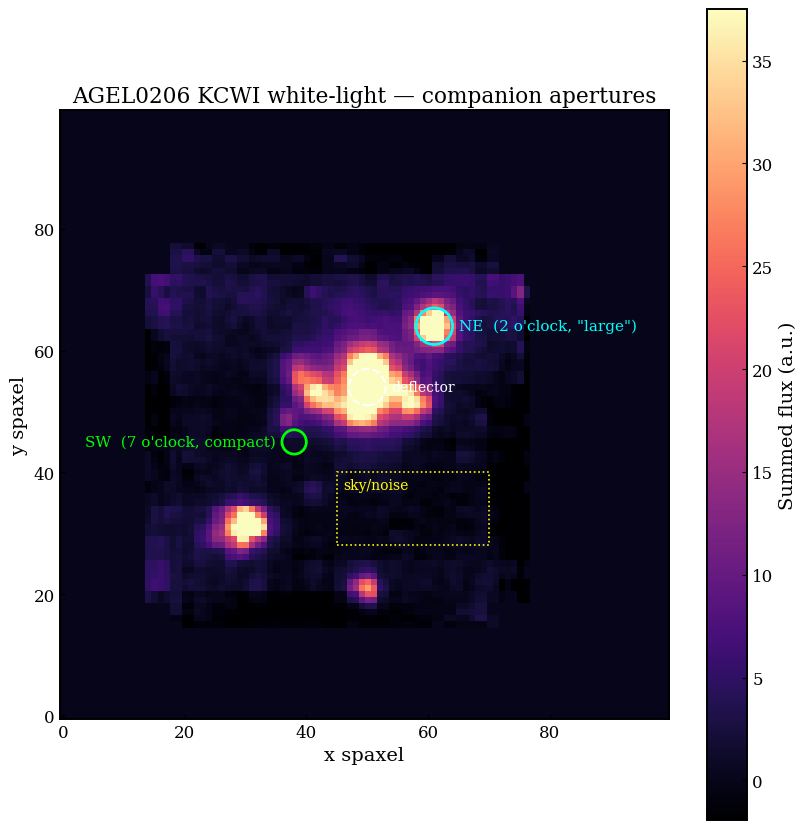

In [2]:
# White-light image (sum over wavelength)
wl_img = np.nansum(cube, axis=0)

# Companion centers (integer spaxel coords, x and y)
NE_CX, NE_CY = 61, 64   # "2 o'clock" — larger
SW_CX, SW_CY = 38, 45   # "7 o'clock" — smaller, quite compact (just SW of deflector)
DEFL_CX, DEFL_CY = 50, 54

# Aperture radius in spaxels (1 spaxel = 0.30")
APER_R_NE = 3   # 0.9" radius — matches seeing FWHM=1.27" for the larger NE
APER_R_SW = 2   # 0.6" radius — tighter, since the SW source is compact
APER_R_DEFL = 3

# Build circular boolean masks
yy, xx = np.indices(wl_img.shape)
def circ_mask(cy, cx, r):
    return (yy - cy)**2 + (xx - cx)**2 <= r**2

mask_NE   = circ_mask(NE_CY, NE_CX, APER_R_NE)
mask_SW   = circ_mask(SW_CY, SW_CX, APER_R_SW)
mask_defl = circ_mask(DEFL_CY, DEFL_CX, APER_R_DEFL)

print(f"NE aperture (r={APER_R_NE}): center (y,x)=({NE_CY},{NE_CX}) -> {mask_NE.sum()} spaxels")
print(f"SW aperture (r={APER_R_SW}): center (y,x)=({SW_CY},{SW_CX}) -> {mask_SW.sum()} spaxels")
print(f"Deflector reference (r={APER_R_DEFL}): -> {mask_defl.sum()} spaxels")

# Sky/noise region — same one used in nb04 (verified inside the IFU footprint
# and clear of all three galaxies). The cube has zero-flux padding outside
# the IFU rectangle but the per-pixel std is still nonzero, so this works.
sky_y0, sky_y1, sky_x0, sky_x1 = 28, 40, 45, 70
print(f"Sky rectangle for noise: y={sky_y0}:{sky_y1}, x={sky_x0}:{sky_x1}")

# Plot
fig, ax = plt.subplots(figsize=(8.5, 8.5))
vmin, vmax = np.nanpercentile(wl_img, [3, 99])
im = ax.imshow(wl_img, origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
plt.colorbar(im, ax=ax, label='Summed flux (a.u.)')

ax.add_patch(Circle((NE_CX, NE_CY),     APER_R_NE,   ec='cyan',  fc='none', lw=2))
ax.add_patch(Circle((SW_CX, SW_CY),     APER_R_SW,   ec='lime',  fc='none', lw=2))
ax.add_patch(Circle((DEFL_CX, DEFL_CY), APER_R_DEFL, ec='white', fc='none', lw=1.5, ls='--'))
ax.add_patch(Rectangle((sky_x0, sky_y0), sky_x1-sky_x0, sky_y1-sky_y0,
                       ec='yellow', fc='none', lw=1.2, ls=':'))

ax.text(NE_CX+APER_R_NE+1, NE_CY,    'NE  (2 o\'clock, "large")',  color='cyan',  fontsize=11, va='center')
ax.text(SW_CX-APER_R_SW-1, SW_CY,    'SW  (7 o\'clock, compact)',  color='lime',  fontsize=11, ha='right', va='center')
ax.text(DEFL_CX+APER_R_DEFL+1, DEFL_CY, 'deflector',               color='white', fontsize=10, va='center')
ax.text(sky_x0+1, sky_y1-1,          'sky/noise',                 color='yellow', fontsize=10, va='top')

ax.set_xlabel('x spaxel')
ax.set_ylabel('y spaxel')
ax.set_title('AGEL0206 KCWI white-light — companion apertures')
plt.tight_layout()
plt.show()

## 3. Extract integrated spectra for the two companions

Spectra extracted — length 3317 pixels each.
Noise spec: median = 0.00338, floor applied to 2 zero-pixels.
Median S/N in 6500-7500 Å:
  NE        : 4.23
  SW        : 0.27
  defl_ref  : 5.62


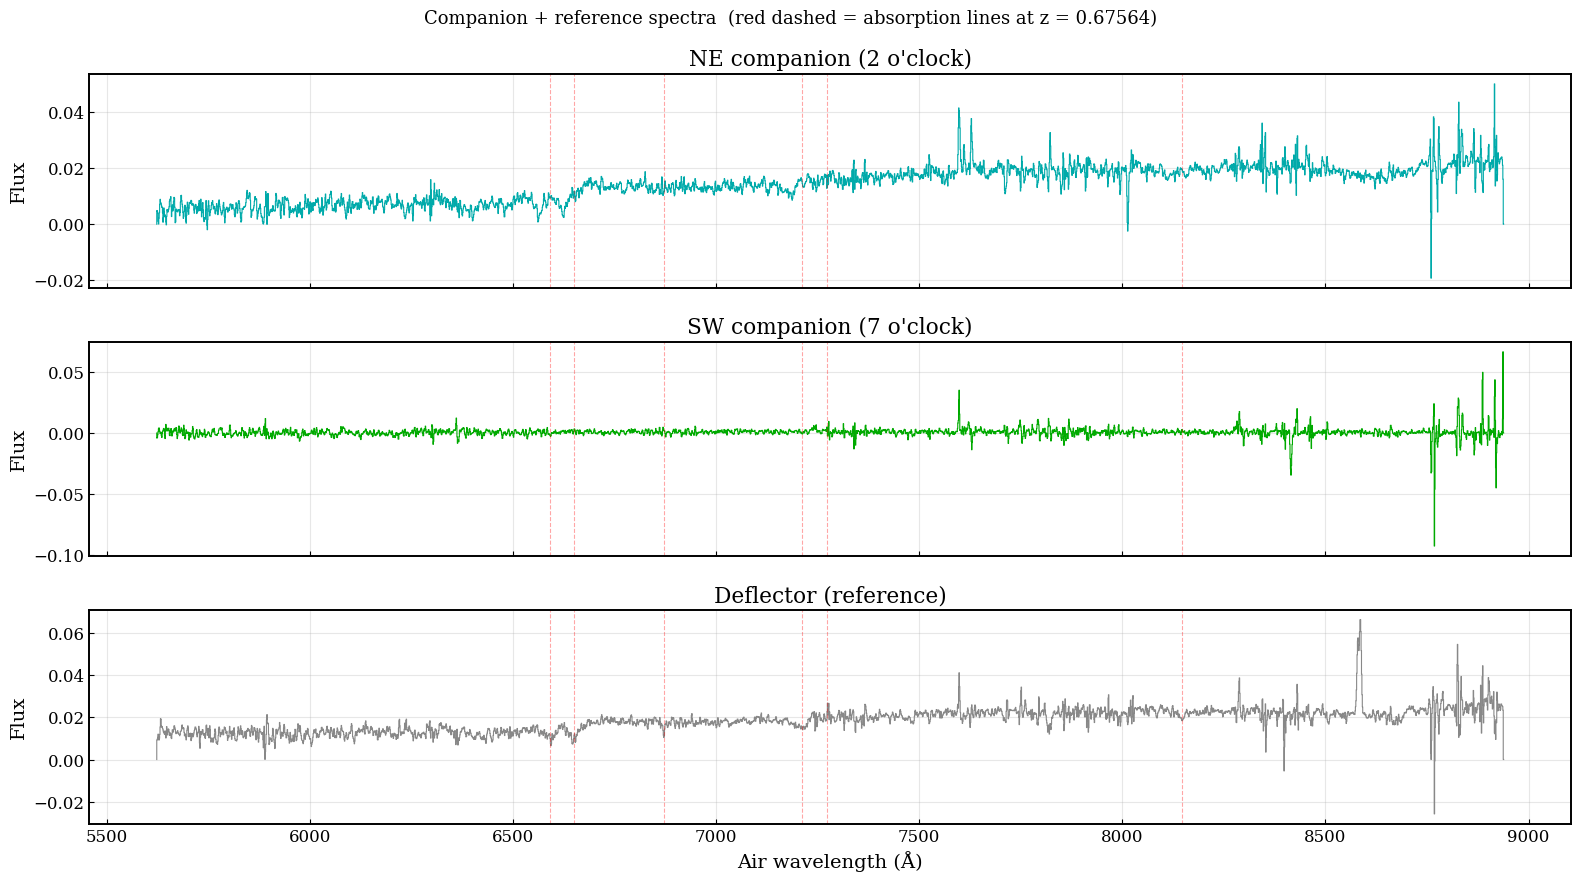

In [3]:
# Integrated (mean) spectrum within each circular aperture, plus a noise
# spectrum from the sky rectangle.
def aper_mean(cube, mask):
    """Mean spectrum over a 2-D boolean spaxel mask, ignoring NaNs."""
    sub = cube[:, mask]   # shape (n_lam, n_spax)
    return np.nanmean(sub, axis=1)

flux_NE = aper_mean(cube, mask_NE)
flux_SW = aper_mean(cube, mask_SW)
flux_defl_ref = aper_mean(cube, mask_defl)   # reference for sanity

# Noise: per-pixel std across the sky rectangle (matches notebook 04 convention).
# Replace any zero/NaN entries with the median to keep curve_fit happy.
noise_raw = np.nanstd(cube[:, sky_y0:sky_y1, sky_x0:sky_x1], axis=(1, 2))
noise_floor = np.nanmedian(noise_raw[noise_raw > 0]) * 0.1
noise_spec = np.where(np.isfinite(noise_raw) & (noise_raw > 0), noise_raw, noise_floor)

print(f"Spectra extracted — length {flux_NE.size} pixels each.")
print(f"Noise spec: median = {np.nanmedian(noise_spec):.3g}, "
      f"floor applied to {np.sum(noise_raw == 0)} zero-pixels.")
band = (lam_air > 6500) & (lam_air < 7500)
print(f"Median S/N in 6500-7500 Å:")
for name, f in [('NE', flux_NE), ('SW', flux_SW), ('defl_ref', flux_defl_ref)]:
    sn = np.nanmedian(f[band] / noise_spec[band])
    print(f"  {name:<10}: {sn:.2f}")

# Plot the three spectra
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
for ax, f, name, color in zip(
        axes,
        [flux_NE, flux_SW, flux_defl_ref],
        ['NE companion (2 o\'clock)', 'SW companion (7 o\'clock)', 'Deflector (reference)'],
        ['#0aa', '#0a0', '#888']):
    ax.step(lam_air, f, color=color, lw=0.8)
    ax.set_ylabel('Flux')
    ax.set_title(name)
    ax.grid(alpha=0.3)
    # Mark deflector-frame absorption lines for visual reference
    for lname, info in {'Ca K': 3933.66, 'Ca H': 3968.47,
                        'Hδ': 4101.74, 'G-band': 4304.40,
                        'Hγ': 4340.47, 'Hβ': 4861.33}.items():
        wl = info * (1 + Z_DEFLECTOR)
        if lam_air[0] < wl < lam_air[-1]:
            ax.axvline(wl, color='red', ls='--', alpha=0.35, lw=0.8)
axes[-1].set_xlabel('Air wavelength (Å)')
fig.suptitle(f"Companion + reference spectra  (red dashed = absorption lines at z = {Z_DEFLECTOR})",
             fontsize=13)
plt.tight_layout()
plt.show()

## 4. Fit absorption + emission lines at the deflector redshift

We use the same Gaussian fitter as notebook 04. **Absorption** lines
(Ca K, Ca H, Hδ, G-band, Hγ, Hβ) are stellar features expected if the
companion is a passive/early-type galaxy at z ≈ 0.676. **Emission**
lines ([OII], Hβ, [OIII]) at the same z would mean the companion is
star-forming but still in the deflector plane.

If neither set of fits clusters near z = 0.676, the galaxy is *not*
in the foreground plane.

In [4]:
DEFLECTOR_ABS_LINES = {
    'Ca K':    {'lambda': 3933.66, 'label': 'Ca K'},
    'Ca H':    {'lambda': 3968.47, 'label': 'Ca H'},
    'H-delta': {'lambda': 4101.74, 'label': r'H$\delta$'},
    'G-band':  {'lambda': 4304.40, 'label': 'G-band'},
    'H-gamma': {'lambda': 4340.47, 'label': r'H$\gamma$'},
    'H-beta':  {'lambda': 4861.33, 'label': r'H$\beta$'},
}

DEFLECTOR_EM_LINES = {
    '[O II] 3726':  {'lambda': 3726.03, 'label': '[O II] 3726'},
    '[O II] 3729':  {'lambda': 3728.82, 'label': '[O II] 3729'},
    'H-beta em':    {'lambda': 4861.33, 'label': r'H$\beta$ em'},
    '[O III] 4959': {'lambda': 4958.91, 'label': '[O III] 4959'},
    '[O III] 5007': {'lambda': 5006.84, 'label': '[O III] 5007'},
}

def fit_at_z(flux, z_guess, label):
    """Fit absorption + emission line dictionaries at a single z_guess and
    print a per-line table. Returns (abs_result, em_result)."""
    abs_r = verify_redshift(lam_air, flux, z_guess=z_guess, noise=noise_spec,
                            line_dict=DEFLECTOR_ABS_LINES, emission=False,
                            window_angstrom=30.0)
    em_r  = verify_redshift(lam_air, flux, z_guess=z_guess, noise=noise_spec,
                            line_dict=DEFLECTOR_EM_LINES, emission=True,
                            window_angstrom=30.0)

    print(f"\n=== {label}  (z_guess = {z_guess}) ===")
    print(f"{'line':<18} {'mode':<5} {'z_fit':>10} {'z_err':>10} {'sigma(Å)':>10}")
    print('-' * 60)
    for nm, r in abs_r['per_line'].items():
        if r['success']:
            print(f"{nm:<18} {'abs':<5} {r['z_fit']:10.5f} {r['z_err']:10.5f} {r.get('sigma',np.nan):10.2f}")
        else:
            print(f"{nm:<18} {'abs':<5} {'FAILED':>10}")
    for nm, r in em_r['per_line'].items():
        if r['success']:
            print(f"{nm:<18} {'em':<5} {r['z_fit']:10.5f} {r['z_err']:10.5f} {r.get('sigma',np.nan):10.2f}")
        else:
            print(f"{nm:<18} {'em':<5} {'FAILED':>10}")

    if abs_r['n_lines_fit'] > 0:
        print(f"weighted-z (abs) = {abs_r['z_weighted']:.5f} ± {abs_r['z_weighted_err']:.5f}  ({abs_r['n_lines_fit']} lines)")
    if em_r['n_lines_fit'] > 0:
        print(f"weighted-z (em)  = {em_r['z_weighted']:.5f} ± {em_r['z_weighted_err']:.5f}  ({em_r['n_lines_fit']} lines)")
    return abs_r, em_r

ne_abs, ne_em = fit_at_z(flux_NE, Z_DEFLECTOR, "NE companion")
sw_abs, sw_em = fit_at_z(flux_SW, Z_DEFLECTOR, "SW companion")


=== NE companion  (z_guess = 0.67564) ===
line               mode       z_fit      z_err   sigma(Å)
------------------------------------------------------------
Ca K               abs      0.67183 191980.01634       0.50
Ca H               abs      0.67687    0.00023       0.51
H-delta            abs      0.67514    0.00051       1.00
G-band             abs      0.67647    0.00072       1.47
H-gamma            abs      0.67574    0.00020       0.50
H-beta             abs      0.67796    0.00049       3.19
Ca H+K doublet     abs      0.67566    0.05022      20.00
[O II] 3726        em       0.67527    0.00161       0.50
[O II] 3729        em       0.67654    0.00136       0.50
H-beta em          em       0.67555    0.00047       1.97
[O III] 4959       em       0.67532    0.00038       1.08
[O III] 5007       em       0.67603    0.00344       0.50
[OII] doublet      em       0.67534    0.00257       0.52
weighted-z (abs) = 0.67629 ± 0.00014  (7 lines)
weighted-z (em)  = 0.67546 ± 0.000

--- NE companion: absorption line fits ---


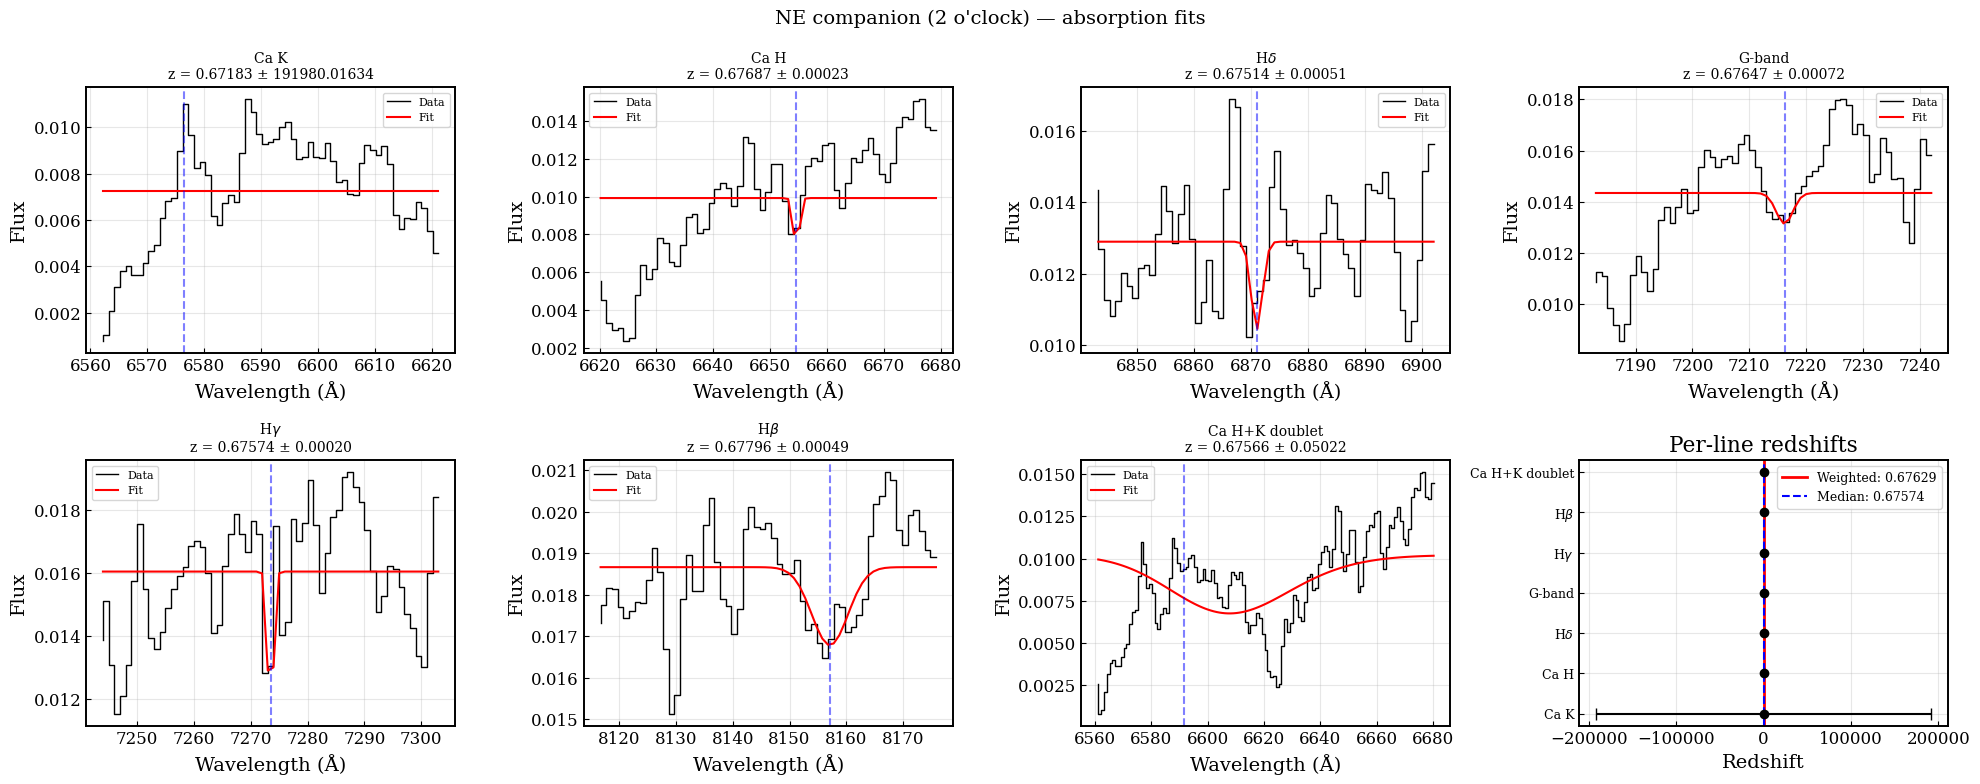

--- SW companion: absorption line fits ---


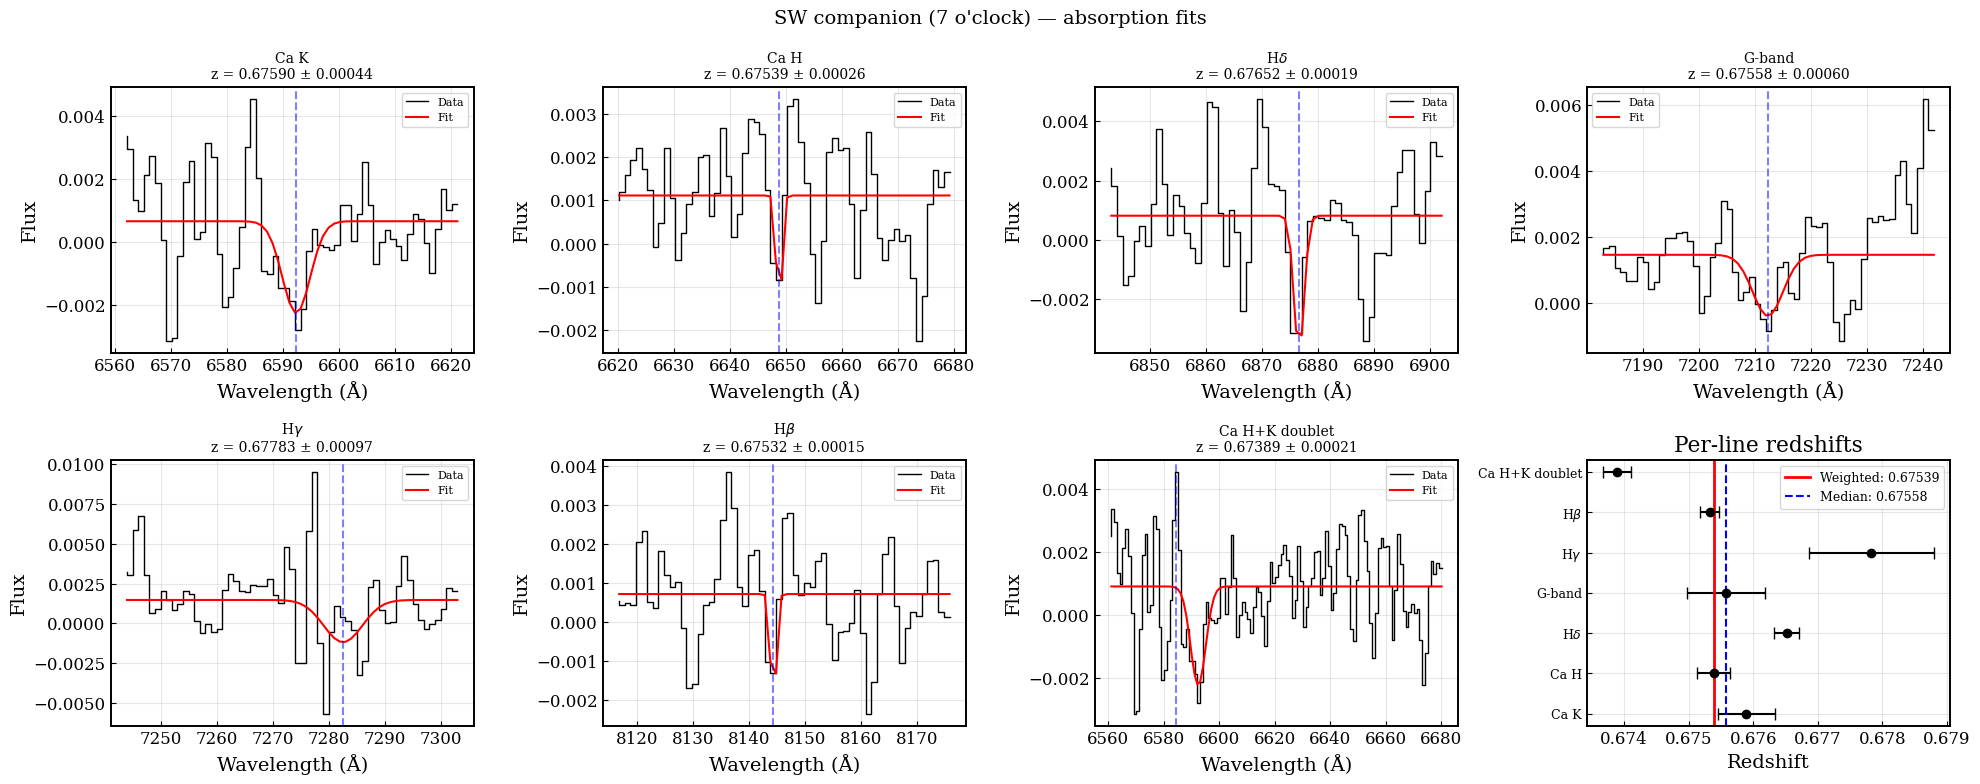

--- Ca H+K doublet (tied width) ---
  NE: z(Ca K)=0.67945 ± 0.01562, z(Ca H)=0.67186 ± 0.09922, avg z=0.67566 ± 0.05022, sigma=20.00 Å
  SW: z(Ca K)=0.67591 ± 0.00043, z(Ca H)=0.67188 ± 0.00000, avg z=0.67389 ± 0.00021, sigma=2.74 Å


In [5]:
# Per-line panel plots for the absorption fits — same style as nb04
print("--- NE companion: absorption line fits ---")
if ne_abs['n_lines_fit'] > 0:
    fig = plot_line_fits(ne_abs, title='NE companion (2 o\'clock) — absorption fits')
    plt.show()

print("--- SW companion: absorption line fits ---")
if sw_abs['n_lines_fit'] > 0:
    fig = plot_line_fits(sw_abs, title='SW companion (7 o\'clock) — absorption fits')
    plt.show()

# Ca H+K doublet (tied width) — single most diagnostic feature for early-types
print("--- Ca H+K doublet (tied width) ---")
ne_cahk = fit_cahk_doublet(lam_air, flux_NE, z_guess=Z_DEFLECTOR,
                           window_angstrom=60.0, noise=noise_spec)
sw_cahk = fit_cahk_doublet(lam_air, flux_SW, z_guess=Z_DEFLECTOR,
                           window_angstrom=60.0, noise=noise_spec)
for tag, r in [('NE', ne_cahk), ('SW', sw_cahk)]:
    if r['success']:
        print(f"  {tag}: z(Ca K)={r['z_cak']:.5f} ± {r['z_cak_err']:.5f}, "
              f"z(Ca H)={r['z_cah']:.5f} ± {r['z_cah_err']:.5f}, "
              f"avg z={r['z_fit']:.5f} ± {r['z_err']:.5f}, sigma={r['sigma']:.2f} Å")
    else:
        print(f"  {tag}: Ca H+K fit FAILED — {r.get('message','')}")

## 5. Interloper check — search for emission-line solutions at other redshifts

If the companion is *not* at z = 0.676, a strong line could be misidentified.
We scan a coarse grid of z_guess values for emission features and report
any line that fits with z_err < 0.001 (a tight, real-looking detection).
This catches background star-forming galaxies that would otherwise hide.

Scanning NE companion ...


Scanning SW companion ...


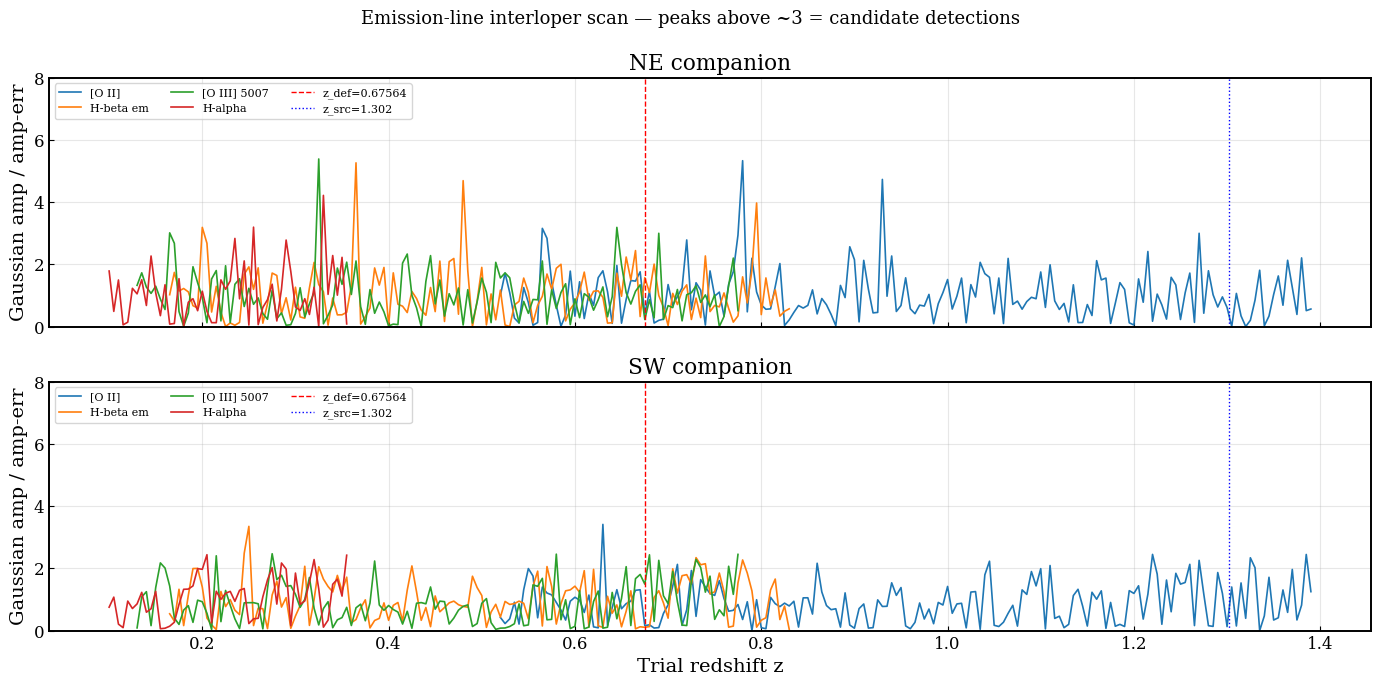


--- NE companion: emission peaks with amp/amp_err > 4.0 ---
  none — no multi-line interloper detected.

--- SW companion: emission peaks with amp/amp_err > 4.0 ---
  none — no multi-line interloper detected.


In [6]:
# Coarse scan: for each candidate redshift, see if [OII]/[OIII]/Hbeta land
# on emission features anywhere in the cube wavelength range.
# z_grid covers the whole regime from foreground (z=0.1) to source (z=1.4).
z_grid = np.arange(0.10, 1.40 + 1e-9, 0.005)

EMISSION_TEST_LINES = {
    '[O II]':       3727.4,    # doublet center (tight blend at our resolution)
    'H-beta em':    4861.33,
    '[O III] 5007': 5006.84,
    'H-alpha':      6562.80,
}

def emission_scan(flux):
    """For each z in z_grid and each emission line, fit a single Gaussian
    and record the fitted line center / amplitude / S/N. Returns a dict
    of arrays indexed by line name."""
    out = {n: {'amp': np.full_like(z_grid, np.nan, dtype=float),
               'amp_err': np.full_like(z_grid, np.nan, dtype=float),
               'z_fit':   np.full_like(z_grid, np.nan, dtype=float),
               'z_err':   np.full_like(z_grid, np.nan, dtype=float),
               'success': np.zeros_like(z_grid, dtype=bool)} for n in EMISSION_TEST_LINES}
    for i, z in enumerate(z_grid):
        for nm, rest in EMISSION_TEST_LINES.items():
            obs_wl = rest * (1 + z)
            if obs_wl < lam_air[0] + 30 or obs_wl > lam_air[-1] - 30:
                continue
            r = rv.fit_single_line(lam_air, flux, rest, z,
                                   window_angstrom=20.0, emission=True,
                                   noise=noise_spec)
            if r['success']:
                out[nm]['amp'][i]     = r['amp']
                out[nm]['z_fit'][i]   = r['z_fit']
                out[nm]['z_err'][i]   = r['z_err']
                out[nm]['success'][i] = True
                # crude amp uncertainty from covariance diagonal[0]
                pcov = r.get('pcov', None)
                if pcov is not None and pcov.size >= 1:
                    out[nm]['amp_err'][i] = float(np.sqrt(np.abs(pcov[0,0])))
    return out

print("Scanning NE companion ...")
scan_NE = emission_scan(flux_NE)
print("Scanning SW companion ...")
scan_SW = emission_scan(flux_SW)

# Plot amplitude / amplitude-error (a poor-man's S/N) vs z for each line
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, scan, label in zip(axes, [scan_NE, scan_SW],
                            ['NE companion', 'SW companion']):
    for nm, d in scan.items():
        sn = d['amp'] / d['amp_err']
        ax.plot(z_grid, sn, label=nm, lw=1.2)
    ax.axvline(Z_DEFLECTOR, color='red', ls='--', lw=1, label=f'z_def={Z_DEFLECTOR}')
    ax.axvline(Z_SOURCE,    color='blue', ls=':', lw=1, label=f'z_src={Z_SOURCE}')
    ax.set_ylabel('Gaussian amp / amp-err')
    ax.set_title(label)
    ax.set_ylim(0, max(8, np.nanmax([np.nanmax(d['amp']/d['amp_err']) for d in scan.values()]) * 1.1))
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=3)
axes[-1].set_xlabel('Trial redshift z')
fig.suptitle("Emission-line interloper scan — peaks above ~3 = candidate detections",
             fontsize=13)
plt.tight_layout()
plt.show()

# Report any z with at least 2 lines having amp/amp_err > 4
def report_strong_z(scan, label, threshold=4.0):
    print(f"\n--- {label}: emission peaks with amp/amp_err > {threshold} ---")
    found_any = False
    for i, z in enumerate(z_grid):
        n_strong = sum((scan[nm]['amp'][i] / scan[nm]['amp_err'][i] > threshold)
                       for nm in EMISSION_TEST_LINES
                       if np.isfinite(scan[nm]['amp_err'][i]) and scan[nm]['amp_err'][i] > 0)
        if n_strong >= 2:
            print(f"  z = {z:.3f}: {n_strong} lines pass")
            found_any = True
    if not found_any:
        print("  none — no multi-line interloper detected.")

report_strong_z(scan_NE, "NE companion")
report_strong_z(scan_SW, "SW companion")

## 6. Bootstrap redshift uncertainty for each companion

Same wild-bootstrap (Rademacher × local-residual) used in nb04 §8 and
in `scripts/bootstrap_ppxf.py`. We perturb each companion spectrum
N_BOOT times, refit the absorption (and emission) line dictionaries,
and record the distribution of weighted-average z values.

In [7]:
N_BOOT = 200    # bump to 500 for production

def boot_pair(flux, label):
    """Bootstrap absorption + emission redshifts for one companion."""
    print(f"\n--- bootstrapping {label} (N={N_BOOT}) ---")
    abs_b = bootstrap_redshift(lam_air, flux, noise_spec, z_guess=Z_DEFLECTOR,
                               line_dict=DEFLECTOR_ABS_LINES, emission=False,
                               window_angstrom=30.0, n_bootstrap=N_BOOT, seed=42)
    em_b  = bootstrap_redshift(lam_air, flux, noise_spec, z_guess=Z_DEFLECTOR,
                               line_dict=DEFLECTOR_EM_LINES, emission=True,
                               window_angstrom=30.0, n_bootstrap=N_BOOT, seed=42)
    print(f"  abs:  z = {abs_b['z_p50']:.5f} -{abs_b['z_err_lo']:.5f} +{abs_b['z_err_hi']:.5f}  "
          f"({N_BOOT - abs_b['n_failed']}/{N_BOOT} ok)")
    if N_BOOT - em_b['n_failed'] > 10:
        print(f"  em:   z = {em_b['z_p50']:.5f} -{em_b['z_err_lo']:.5f} +{em_b['z_err_hi']:.5f}  "
              f"({N_BOOT - em_b['n_failed']}/{N_BOOT} ok)")
    else:
        print(f"  em:   no robust emission — only {N_BOOT - em_b['n_failed']}/{N_BOOT} iterations succeeded")
    return abs_b, em_b

ne_abs_b, ne_em_b = boot_pair(flux_NE, "NE companion")
sw_abs_b, sw_em_b = boot_pair(flux_SW, "SW companion")


--- bootstrapping NE companion (N=200) ---


  abs:  z = 0.67580 -0.00067 +0.00062  (200/200 ok)
  em:   z = 0.67565 -0.00045 +0.00060  (200/200 ok)

--- bootstrapping SW companion (N=200) ---


  abs:  z = 0.67588 -0.00034 +0.00047  (200/200 ok)
  em:   z = 0.67558 -0.00048 +0.00071  (200/200 ok)


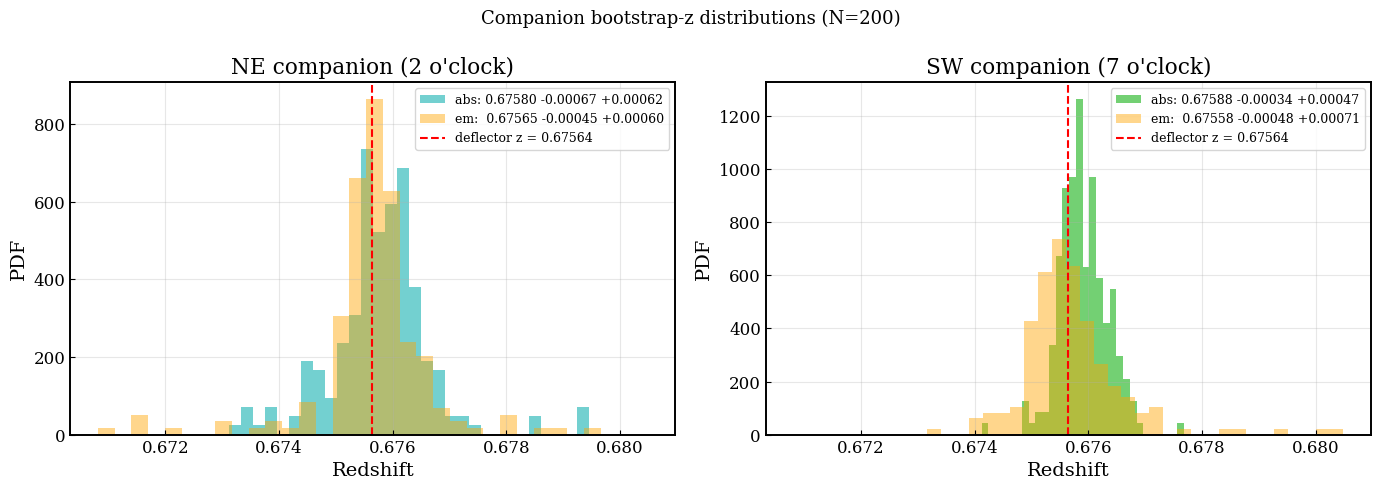

In [8]:
# Bootstrap-z histograms with the deflector reference overlaid
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for ax, abs_b, em_b, label, color in zip(
        axes,
        [ne_abs_b, sw_abs_b],
        [ne_em_b,  sw_em_b],
        ['NE companion (2 o\'clock)', 'SW companion (7 o\'clock)'],
        ['#0aa', '#0a0']):
    valid_abs = abs_b['z_samples'][np.isfinite(abs_b['z_samples'])]
    if len(valid_abs) > 10:
        ax.hist(valid_abs, bins=30, alpha=0.55, color=color, density=True,
                label=f"abs: {abs_b['z_p50']:.5f}"
                      f" -{abs_b['z_err_lo']:.5f} +{abs_b['z_err_hi']:.5f}")
    valid_em = em_b['z_samples'][np.isfinite(em_b['z_samples'])]
    if len(valid_em) > 10:
        ax.hist(valid_em, bins=30, alpha=0.45, color='orange', density=True,
                label=f"em:  {em_b['z_p50']:.5f}"
                      f" -{em_b['z_err_lo']:.5f} +{em_b['z_err_hi']:.5f}")
    ax.axvline(Z_DEFLECTOR, color='red', ls='--', lw=1.5,
               label=f'deflector z = {Z_DEFLECTOR}')
    ax.set_xlabel('Redshift')
    ax.set_ylabel('PDF')
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle(f"Companion bootstrap-z distributions (N={N_BOOT})", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Verdict and summary

We compare each companion's measured redshift to the deflector
systemic z = 0.67564. A companion is **consistent with the foreground
plane** if its bootstrap z lies within ~3σ of z_def (≲ 0.005 in z, or
≲ 1000 km/s in Δv). Larger separations indicate the assumed plane is
wrong and the galaxy is unrelated to the lensing system.

In [9]:
C_KMS = 299792.458

def verdict(label, abs_b, em_b):
    print(f"\n=== {label} ===")
    rows = []
    if N_BOOT - abs_b['n_failed'] > 10:
        z, lo, hi = abs_b['z_p50'], abs_b['z_err_lo'], abs_b['z_err_hi']
        dv = (z - Z_DEFLECTOR) / (1 + Z_DEFLECTOR) * C_KMS
        rows.append(('absorption', z, lo, hi, dv))
    if N_BOOT - em_b['n_failed'] > 10:
        z, lo, hi = em_b['z_p50'], em_b['z_err_lo'], em_b['z_err_hi']
        dv = (z - Z_DEFLECTOR) / (1 + Z_DEFLECTOR) * C_KMS
        rows.append(('emission', z, lo, hi, dv))
    if not rows:
        print("  no usable bootstrap result.")
        return None

    print(f"  {'mode':<10} {'z':>10} {'-':>10} {'+':>10} {'Δv (km/s)':>12}")
    for m, z, lo, hi, dv in rows:
        print(f"  {m:<10} {z:10.5f} {lo:10.5f} {hi:10.5f} {dv:+12.0f}")

    # Choose the higher-S/N (smaller error) mode for the verdict
    rows.sort(key=lambda r: (r[2] + r[3]) / 2)
    best = rows[0]
    z, lo, hi, dv = best[1], best[2], best[3], best[4]
    typical_err = max(0.5*(lo+hi), 1e-5)
    n_sigma = abs(z - Z_DEFLECTOR) / typical_err
    if abs(dv) < 1000:
        verdict_str = f"CONSISTENT with deflector plane (Δv = {dv:+.0f} km/s, {n_sigma:.1f}σ)"
    else:
        verdict_str = f"INCONSISTENT — likely an interloper (Δv = {dv:+.0f} km/s, {n_sigma:.1f}σ)"
    print(f"  → {verdict_str}")
    return {'mode': best[0], 'z': z, 'lo': lo, 'hi': hi, 'dv': dv,
            'n_sigma': n_sigma, 'verdict': verdict_str}

print('=' * 60)
print("AGEL0206 COMPANION REDSHIFT VERDICTS")
print(f"  reference: deflector z = {Z_DEFLECTOR}")
print('=' * 60)
ne_v = verdict("NE companion (2 o'clock, larger)", ne_abs_b, ne_em_b)
sw_v = verdict("SW companion (7 o'clock, smaller)", sw_abs_b, sw_em_b)
print('=' * 60)

AGEL0206 COMPANION REDSHIFT VERDICTS
  reference: deflector z = 0.67564

=== NE companion (2 o'clock, larger) ===
  mode                z          -          +    Δv (km/s)
  absorption    0.67580    0.00067    0.00062          +28
  emission      0.67565    0.00045    0.00060           +2
  → CONSISTENT with deflector plane (Δv = +2 km/s, 0.0σ)

=== SW companion (7 o'clock, smaller) ===
  mode                z          -          +    Δv (km/s)
  absorption    0.67588    0.00034    0.00047          +43
  emission      0.67558    0.00048    0.00071          -12
  → CONSISTENT with deflector plane (Δv = +43 km/s, 0.6σ)


In [10]:
# Save companion-redshift summary to disk for downstream use
import os
os.makedirs('../results', exist_ok=True)

np.savez_compressed(
    '../results/companion_redshifts_04a.npz',
    z_deflector=Z_DEFLECTOR,
    NE_aper_radius=APER_R_NE,
    SW_aper_radius=APER_R_SW,
    NE_center_yx=np.array([NE_CY, NE_CX]),
    SW_center_yx=np.array([SW_CY, SW_CX]),
    NE_abs_z_samples=ne_abs_b['z_samples'],
    NE_em_z_samples=ne_em_b['z_samples'],
    SW_abs_z_samples=sw_abs_b['z_samples'],
    SW_em_z_samples=sw_em_b['z_samples'],
    NE_abs_p50=ne_abs_b['z_p50'],
    NE_abs_err_lo=ne_abs_b['z_err_lo'],
    NE_abs_err_hi=ne_abs_b['z_err_hi'],
    NE_em_p50=ne_em_b['z_p50'],
    NE_em_err_lo=ne_em_b['z_err_lo'],
    NE_em_err_hi=ne_em_b['z_err_hi'],
    SW_abs_p50=sw_abs_b['z_p50'],
    SW_abs_err_lo=sw_abs_b['z_err_lo'],
    SW_abs_err_hi=sw_abs_b['z_err_hi'],
    SW_em_p50=sw_em_b['z_p50'],
    SW_em_err_lo=sw_em_b['z_err_lo'],
    SW_em_err_hi=sw_em_b['z_err_hi'],
    n_bootstrap=N_BOOT,
)
print("Saved -> ../results/companion_redshifts_04a.npz")

Saved -> ../results/companion_redshifts_04a.npz
